**NollySenti:** Multilingual Sentiment Fine-Tuning
**Languages:** English · Yoruba · Hausa | **Dataset:** `Davlan/nollysenti` | **Model:** `Davlan/afro-xlmr-base`

**Code ref:** [IyanuSh/NollySenti](https://github.com/IyanuSh/NollySenti)

In [ ]:
# import shutil, os

# # Remove old checkpoints to retrain
# if os.path.exists(CKPT_DIR):
#     shutil.rmtree(CKPT_DIR)
#     print(f'Deleted: {CKPT_DIR}')

# # Remove old best model
# if os.path.exists(MODEL_DIR):
#     shutil.rmtree(MODEL_DIR)
#     print(f'Deleted: {MODEL_DIR}')

# # Remove old zero-shot model
# if os.path.exists(ZS_DIR):
#     shutil.rmtree(ZS_DIR)

# # Remove tokeniser
# import glob
# for f in glob.glob(f'{DATA_DIR}/**/cache_*.pkl', recursive=True):
#     os.remove(f)
#     print(f'Deleted cache: {f}')

# print('✅ Clean slate — ready to retrain')

Deleted: /content/drive/MyDrive/Colab Notebooks/NollySenti/checkpoints
Deleted: /content/drive/MyDrive/Colab Notebooks/NollySenti/best_model
Deleted cache: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/en/cache_test_afro-xlmr-base_128.pkl
Deleted cache: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/yo/cache_test_afro-xlmr-base_128.pkl
Deleted cache: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/ha/cache_test_afro-xlmr-base_128.pkl
Deleted cache: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/multilingual/cache_train_afro-xlmr-base_128.pkl
Deleted cache: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/multilingual/cache_dev_afro-xlmr-base_128.pkl
✅ Clean slate — ready to retrain


## 0. Check GPU
Change runtime type to T4 GPU

In [ ]:
import subprocess, sys
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if r.returncode != 0:
    sys.exit('⚠️  No GPU! Set Runtime to T4 GPU and restart.')
print('✅ GPU ready')
for line in r.stdout.split('\n'):
    if any(k in line for k in ['Tesla','T4','A100','L4','V100','A10']):
        print(' ', line.strip()); break

✅ GPU ready
  |   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |


## 1. Mount Google Drive
Save data, checkpoints, results, plots under `My Drive/Colab Notebooks/NollySenti/`

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os

# ── All paths rooted in Drive ──────────────────────────────────────────────
DRIVE_ROOT  = '/content/drive/MyDrive/Colab Notebooks/NollySenti'
DATA_DIR    = f'{DRIVE_ROOT}/data'
OUTPUT_DIR  = f'{DRIVE_ROOT}/outputs'
MODEL_DIR   = f'{DRIVE_ROOT}/best_model'
ZS_DIR      = f'{DRIVE_ROOT}/zeroshot_model'
CKPT_DIR    = f'{DRIVE_ROOT}/checkpoints'

for d in [DATA_DIR, OUTPUT_DIR, MODEL_DIR, ZS_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

print('✅ Drive mounted. Project folder structure:')
for d in [DATA_DIR, OUTPUT_DIR, MODEL_DIR, ZS_DIR, CKPT_DIR]:
    print(f'  {d}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted. Project folder structure:
  /content/drive/MyDrive/Colab Notebooks/NollySenti/data
  /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs
  /content/drive/MyDrive/Colab Notebooks/NollySenti/best_model
  /content/drive/MyDrive/Colab Notebooks/NollySenti/zeroshot_model
  /content/drive/MyDrive/Colab Notebooks/NollySenti/checkpoints


## 2. Install Dependencies

In [ ]:
# Install compatible package versions
import subprocess, sys

pkgs = [
    'transformers==4.44.2',
    'datasets==2.20.0',
    'evaluate==0.4.2',
    'accelerate==0.33.0',
    'scikit-learn',
    'seaborn',
    'matplotlib',
    'tensorflow',
    'numpy'
]

print('Installing packages...')
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade', '--force-reinstall'] + pkgs,
    capture_output=True, text=True
)
if result.returncode != 0:
    print('STDERR:', result.stderr[-500:])
else:
    print('✅ All packages installed')

# Force reload of transformers in current runtime
import importlib, sys as _sys
mods_to_reload = [k for k in _sys.modules if k.startswith('transformers')]
for mod in mods_to_reload:
    _sys.modules.pop(mod, None)

import transformers
print(f'transformers version loaded: {transformers.__version__}')

# Verify import works
try:
    from transformers import Trainer, AutoModelForSequenceClassification
    print('✅ Trainer import OK')
except ImportError as e:
    print(f'❌ Still failing: {e}')
    print('Restart session, then re-run the cell')

Installing packages...
✅ All packages installed
transformers version loaded: 4.44.2
✅ Trainer import OK


### Fixing PyTorch and Torchvision CUDA Version Mismatch

Uninstall and then reinstall compatible versions.

In [ ]:
import subprocess
import sys

print('Uninstalling existing torch, torchvision, and transformers...')

# Uninstall existing packages to ensure a clean install
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y', 'torch', 'torchvision', 'transformers'], capture_output=True, text=True)

print('Reinstalling torch, torchvision, and transformers for CUDA 13.0...')
# Reinstall torch and torchvision for CUDA 13.0, and transformers
# Using --force-reinstall to ensure all dependencies are properly handled
pip_command = [
    sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade', '--force-reinstall',
    'torch', 'torchvision',
    '-f', 'https://download.pytorch.org/whl/cu130'
]
result_torch = subprocess.run(pip_command, capture_output=True, text=True)

if result_torch.returncode != 0:
    print('STDERR (torch/torchvision):', result_torch.stderr)
    sys.exit('❌ Failed to reinstall torch/torchvision. Please check the PyTorch website for installation instructions for your specific CUDA version.')

pip_command_transformers = [
    sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade', '--force-reinstall',
    'transformers==4.44.2' # Pinning to the version used in the notebook
]
result_transformers = subprocess.run(pip_command_transformers, capture_output=True, text=True)

if result_transformers.returncode != 0:
    print('STDERR (transformers):', result_transformers.stderr)
    sys.exit('❌ Failed to reinstall transformers.')

print('✅ torch, torchvision, and transformers reinstalled successfully.')
print('\n⚠️  Please RESTART RUNTIME (Runtime > Restart session) and then re-run all cells from the beginning to apply changes and verify the fix.')

# Verify import works after reinstall (though a runtime restart is crucial)
try:
    import torch
    import torchvision
    import transformers
    print(f'\nPyTorch version: {torch.__version__}, CUDA: {torch.version.cuda}')
    print(f'Torchvision version: {torchvision.__version__}') # torchvision.version.cuda might not always be directly available
    print(f'Transformers version: {transformers.__version__}')
    print('✅ Initial verification suggests packages are installed. Full functionality requires runtime restart.')
except ImportError as e:
    print(f'❌ Verification failed after reinstall (before runtime restart): {e}')
    print('Restart session, then re-run all cells from the beginning.')

Uninstalling existing torch, torchvision, and transformers...
Reinstalling torch, torchvision, and transformers for CUDA 13.0...
✅ torch, torchvision, and transformers reinstalled successfully.

⚠️  Please RESTART RUNTIME (Runtime > Restart session) and then re-run all cells from the beginning to apply changes and verify the fix.
❌ Verification failed after reinstall (before runtime restart): cannot import name '_Ink' from 'PIL._typing' (/usr/local/lib/python3.12/dist-packages/PIL/_typing.py)
Restart session, then re-run all cells from the beginning.


In [ ]:
import random, logging, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, concatenate_datasets
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, set_seed
)
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
)
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

SEED = 42
set_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
if DEVICE == 'cuda':
    p = torch.cuda.get_device_properties(0)
    print(f'GPU: {p.name} | VRAM: {p.total_memory/1e9:.1f} GB')

PyTorch 2.11.0+cu130 | Device: cuda
GPU: Tesla T4 | VRAM: 15.6 GB


## 3. Configuration

**Label order:** positive=0, negative=1.

In [ ]:
MODEL_NAME   = 'Davlan/afro-xlmr-base'   # AfroXLM-R
LANGUAGES    = ['en', 'yo', 'ha']         # English, Yoruba, Hausa
TRAIN_MODE   = 'multilingual'             # 'multilingual' | 'english_only'

# Hyperparameters
MAX_LEN       = 128
BATCH_SIZE    = 16
GRAD_ACCUM    = 1
LEARNING_RATE = 2e-5
WEIGHT_DECAY  = 0.01
ADAM_EPSILON  = 1e-8
MAX_GRAD_NORM = 1.0
NUM_EPOCHS    = 5
WARMUP_RATIO  = 0.1

# Label map
LABELS   = ['positive', 'negative']
LABEL2ID = {l: i for i, l in enumerate(LABELS)}  # {'positive':0, 'negative':1}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}  # {0:'positive', 1:'negative'}

LANG_META = {
    'en': {'name': 'English', 'col': 'en_review', 'nllb': 'eng_Latn'},
    'yo': {'name': 'Yoruba',  'col': 'yo_review', 'nllb': 'yor_Latn'},
    'ha': {'name': 'Hausa',   'col': 'ha_review', 'nllb': 'hau_Latn'},
}

print(f'  Model: {MODEL_NAME}')
print(f'  Label map: {LABEL2ID} ')
print(f'  Drive root: {DRIVE_ROOT}')

  Model: Davlan/afro-xlmr-base
  Label map: {'positive': 0, 'negative': 1} 
  Drive root: /content/drive/MyDrive/Colab Notebooks/NollySenti


## 4. Session Resume Check
**This cell auto-detects what's already saved on Drive.** If a trained model exists, skip to part 10 (Evaluation) without retraining.

In [ ]:
import glob, json

model_exists = os.path.exists(os.path.join(MODEL_DIR, 'config.json'))
data_exists  = os.path.exists(os.path.join(DATA_DIR, 'multilingual', 'train.tsv'))
results_exist = os.path.exists(os.path.join(OUTPUT_DIR, 'summary_results.csv'))

print(' Drive state:')
print(f'  Data (TSVs)       : {"✅ exists — skip part5-6" if data_exists  else "❌ run part5"}')
print(f'  Trained model     : {"✅ exists — skip part7-9" if model_exists else "❌ run part7-9"}')
print(f'  Results/plots     : {"✅ exists — skip part10" if results_exist else "❌ run part10"}')

if model_exists:
    print('\n Model already trained.')
    print('Run part2-4 (setup), then part10 (Evaluation).')
    try:
        log_path = os.path.join(OUTPUT_DIR, 'experiment_log.json')
        if os.path.exists(log_path):
            with open(log_path) as f:
                prev = json.load(f)
            print(f'   Previous run: {prev.get("date","?")} | '
                  f'Best val F1: {prev.get("best_f1_val","?")}')
    except:
        pass
else:
    print('\n No saved model found - run all cells')

 Drive state:
  Data (TSVs)       : ✅ exists — skip part5-6
  Trained model     : ❌ run part7-9
  Results/plots     : ❌ run part10

 No saved model found - run all cells


## 5. Load Dataset & Save TSVs to Drive
Downloads from HuggingFace once, saves `.tsv`. **Skipped automatically if files already exist on Drive.**

In [ ]:
SPLIT_MAP = {'train': 'train', 'validation': 'dev', 'test': 'test'} #rename dev to validation

def save_tsv(examples, lang, hf_split, out_dir):
    col   = LANG_META[lang]['col']
    fname = os.path.join(out_dir, f'{SPLIT_MAP[hf_split]}.tsv')
    with open(fname, 'w', encoding='utf-8') as f:
        f.write('text\tsentiment\n')
        for ex in examples:
            text = ex[col].replace('\t',' ').replace('\n',' ')
            f.write(f"{text}\t{ex['sentiment']}\n")
    return fname

raw_data = {}
for lang in LANGUAGES:
    lang_dir = os.path.join(DATA_DIR, lang)
    os.makedirs(lang_dir, exist_ok=True)
    raw_data[lang] = load_dataset('Davlan/nollysenti', lang)
    meta = LANG_META[lang]
    for hf_split in ['train', 'validation', 'test']:
        tsv_path = os.path.join(lang_dir, f'{SPLIT_MAP[hf_split]}.tsv')
        if not os.path.exists(tsv_path):
            save_tsv(raw_data[lang][hf_split], lang, hf_split, lang_dir)
            print(f'  Saved: {tsv_path}')
        else:
            print(f'  Exists: {tsv_path}')
    print(f'{meta["name"]:10}: train={len(raw_data[lang]["train"]):,} | '
          f'val={len(raw_data[lang]["validation"]):,} | test={len(raw_data[lang]["test"]):,}')

# Multilingual merged TSV
multi_dir = os.path.join(DATA_DIR, 'multilingual')
os.makedirs(multi_dir, exist_ok=True)
for hf_split in ['train', 'validation', 'test']:
    path = os.path.join(multi_dir, f'{SPLIT_MAP[hf_split]}.tsv')
    if not os.path.exists(path):
        with open(path, 'w', encoding='utf-8') as f:
            f.write('text\tsentiment\n')
            for lang in LANGUAGES:
                col = LANG_META[lang]['col']
                for ex in raw_data[lang][hf_split]:
                    text = ex[col].replace('\t',' ').replace('\n',' ')
                    f.write(f"{text}\t{ex['sentiment']}\n")
        print(f'  Saved multilingual: {path}')

print('\n All TSVs saved to Drive ')

README.md: 0.00B [00:00, ?B/s]

train.tsv: 0.00B [00:00, ?B/s]

dev.tsv: 0.00B [00:00, ?B/s]

test.tsv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1302 [00:00<?, ? examples/s]

...

test.tsv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

  Exists: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/ha/train.tsv
  Exists: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/ha/dev.tsv
  Exists: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/ha/test.tsv
Hausa     : train=410 | val=100 | test=500

 All TSVs saved to Drive 


## 6. Exploratory Data Analysis

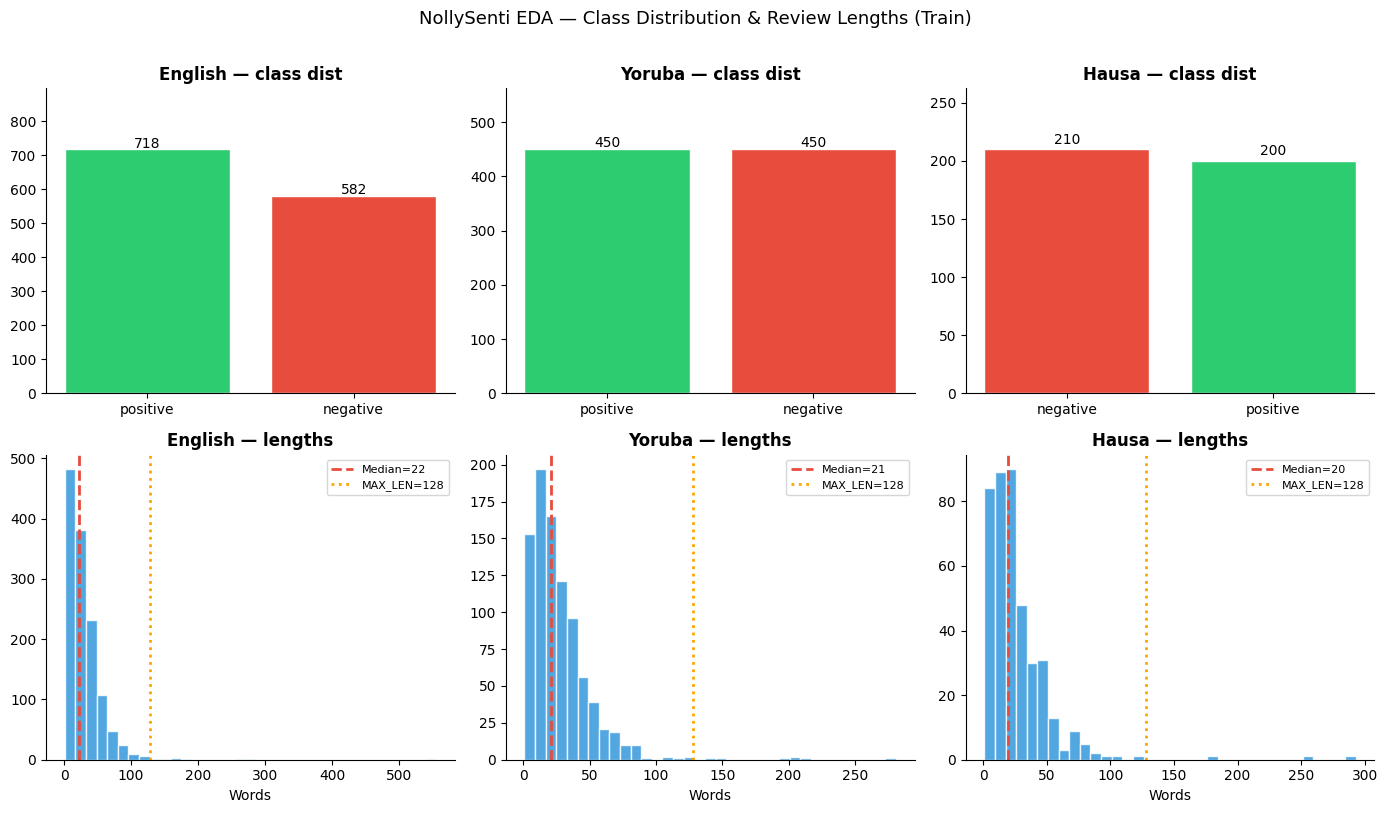

Saved to Drive: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/eda.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
palette = {'positive': '#2ecc71', 'negative': '#e74c3c'}

for i, lang in enumerate(LANGUAGES):
    df   = raw_data[lang]['train'].to_pandas()
    col  = LANG_META[lang]['col']
    name = LANG_META[lang]['name']

    # Class distribution
    ax1    = axes[0, i]
    counts = df['sentiment'].value_counts()
    bars   = ax1.bar(counts.index, counts.values,
                     color=[palette[k] for k in counts.index], edgecolor='white')
    ax1.set_title(f'{name} — class dist', fontweight='bold')
    ax1.set_ylim(0, counts.max() * 1.25)
    ax1.spines[['top','right']].set_visible(False)
    for b, v in zip(bars, counts.values):
        ax1.text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v), ha='center', fontsize=10)

    # Length distribution
    ax2   = axes[1, i]
    wlen  = df[col].str.split().str.len()
    ax2.hist(wlen, bins=35, color='#3498db', alpha=0.85, edgecolor='white')
    ax2.axvline(wlen.median(), color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Median={wlen.median():.0f}')
    ax2.axvline(MAX_LEN, color='orange', linestyle=':', linewidth=2,
                label=f'MAX_LEN={MAX_LEN}')
    ax2.set_title(f'{name} — lengths', fontweight='bold')
    ax2.set_xlabel('Words'); ax2.legend(fontsize=8)
    ax2.spines[['top','right']].set_visible(False)

plt.suptitle('NollySenti EDA — Class Distribution & Review Lengths (Train)', fontsize=13, y=1.01)
plt.tight_layout()
eda_path = os.path.join(OUTPUT_DIR, 'eda.png')
plt.savefig(eda_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to Drive: {eda_path}')

## 7. Data Utilities
Logic: `Instance`, `InputFeatures`, `read_instances_from_file`, `convert_instances_to_features`.

In [ ]:
class Instance:
    def __init__(self, text, label): self.text = text; self.label = label

class InputFeatures:
    def __init__(self, input_ids, attention_mask, token_type_ids, label):
        self.input_ids=input_ids; self.attention_mask=attention_mask
        self.token_type_ids=token_type_ids; self.label=label

def read_instances_from_file(data_dir, mode, delimiter='\t'):
    path = os.path.join(data_dir, f'{mode}.tsv')
    instances = []
    with open(path, 'r', encoding='utf-8') as f:
        lines = f.read().splitlines()
    for l, line in enumerate(lines):
        if l == 0: continue
        parts = line.strip().split(delimiter)
        instances.append(Instance(' '.join(parts[:-1]), parts[-1]))
    return instances

def convert_instances_to_features(instances, tokenizer, labels, max_seq_length):
    label_map = {l: i for i, l in enumerate(labels)}
    features, skipped = [], 0
    for idx, inst in enumerate(instances):
        enc = tokenizer.encode_plus(text=inst.text, max_length=max_seq_length,
                                    pad_to_max_length=True, truncation=True)
        try:    tok_type = enc['token_type_ids']
        except: tok_type = [0] * len(enc['input_ids'])
        if inst.label not in label_map: skipped += 1; continue
        if idx < 2:
            print(f'  [ex {idx}] label={inst.label}→{label_map[inst.label]} | '
                  f'text={inst.text[:50]}...')
        features.append(InputFeatures(enc['input_ids'], enc['attention_mask'],
                                      tok_type, label_map[inst.label]))
    if skipped: print(f'  Skipped {skipped} unknown-label instances')
    return features

def features_to_dataset(features, model_type='xlmroberta'):
    from torch.utils.data import TensorDataset
    ids   = torch.tensor([f.input_ids      for f in features], dtype=torch.long)
    mask  = torch.tensor([f.attention_mask for f in features], dtype=torch.long)
    lbls  = torch.tensor([f.label          for f in features], dtype=torch.long)
    ttype = mask.clone() if model_type == 'xlmroberta' else \
            torch.tensor([f.token_type_ids for f in features], dtype=torch.long)
    return TensorDataset(ids, mask, ttype, lbls)

class TensorDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, td): self.td = td
    def __len__(self): return len(self.td)
    def __getitem__(self, i):
        ids, mask, _, lbl = self.td[i]
        return {'input_ids': ids, 'attention_mask': mask, 'labels': lbl}

MODEL_TYPE = 'xlmroberta' if any(k in MODEL_NAME.lower() for k in ['xlm-r','afro-xlmr']) else 'bert'
print(f'Utilities ready | model_type detected: {MODEL_TYPE}')

Utilities ready | model_type detected: xlmroberta


## 8. Tokenise
Loads TSVs from Drive, tokenises with `encode_plus`, caches features to Drive so re-tokenisation is skipped on resume.

In [ ]:
import pickle

def load_and_tokenize(data_dir_path, mode, tokenizer, model_type):
    cache = os.path.join(data_dir_path, f'cache_{mode}_{MODEL_NAME.split("/")[-1]}_{MAX_LEN}.pkl')
    if os.path.exists(cache):
        print(f'  Loading from cache: {cache}')
        with open(cache, 'rb') as f: features = pickle.load(f)
    else:
        instances = read_instances_from_file(data_dir_path, mode)
        print(f'  Tokenising {len(instances)} instances ({mode})...')
        features = convert_instances_to_features(instances, tokenizer, LABELS, MAX_LEN)
        with open(cache, 'wb') as f: pickle.dump(features, f)
        print(f'  Cached to Drive: {cache}')
    return TensorDatasetWrapper(features_to_dataset(features, model_type))

print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

ACTIVE_DATA = os.path.join(DATA_DIR, 'multilingual' if TRAIN_MODE == 'multilingual' else 'en')

print(f'\nTokenising TRAIN ({TRAIN_MODE})...')
train_ds = load_and_tokenize(ACTIVE_DATA, 'train', tokenizer, MODEL_TYPE)
print(f'\nTokenising VAL ({TRAIN_MODE})...')
val_ds   = load_and_tokenize(ACTIVE_DATA, 'dev',   tokenizer, MODEL_TYPE)

test_ds = {}
for lang in LANGUAGES:
    print(f'\nTokenising TEST ({lang})...')
    test_ds[lang] = load_and_tokenize(os.path.join(DATA_DIR, lang), 'test', tokenizer, MODEL_TYPE)

print(f'\n✅ Tokenisation complete')
print(f'  Train: {len(train_ds):,} | Val: {len(val_ds):,}')
for lang in LANGUAGES:
    print(f'  Test ({lang}): {len(test_ds[lang]):,}')

Loading tokenizer: Davlan/afro-xlmr-base

Tokenising TRAIN (multilingual)...
  Loading from cache: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/multilingual/cache_train_afro-xlmr-base_128.pkl

Tokenising VAL (multilingual)...
  Loading from cache: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/multilingual/cache_dev_afro-xlmr-base_128.pkl

Tokenising TEST (en)...
  Loading from cache: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/en/cache_test_afro-xlmr-base_128.pkl

Tokenising TEST (yo)...
  Loading from cache: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/yo/cache_test_afro-xlmr-base_128.pkl

Tokenising TEST (ha)...
  Loading from cache: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/ha/cache_test_afro-xlmr-base_128.pkl

✅ Tokenisation complete
  Train: 2,610 | Val: 300
  Test (en): 500
  Test (yo): 500
  Test (ha): 500


## 9. Fine-Tune
**Skip this section if a model already exists on Drive** (part4 will tell you). Checkpoints saved to Drive every epoch — if session crashes mid-training, resume by re-running this cell: the Trainer picks up from the latest Drive checkpoint.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy' : float(accuracy_score(labels, preds)),
        'precision_weighted': float(precision_score(labels, preds, average='weighted', zero_division=0)),
        'recall_weighted'   : float(recall_score(labels, preds,    average='weighted', zero_division=0)),
        'f1_macro' : float(f1_score(labels, preds, average='macro')),
        'f1_pos'   : float(f1_score(labels, preds, pos_label=LABEL2ID['positive'], average='binary')),
        'f1_neg'   : float(f1_score(labels, preds, pos_label=LABEL2ID['negative'], average='binary')),
    }

# Check if we should resume from existing Drive checkpoint
ckpts = []
if os.path.exists(CKPT_DIR):
    all_items = os.listdir(CKPT_DIR)
    ckpts = [d for d in all_items if d.startswith('checkpoint-')]

resume_from = None
if ckpts:
    latest_ckpt_dir = os.path.join(CKPT_DIR, sorted(ckpts)[-1])
    # Check for a critical file to ensure it's a valid checkpoint
    if os.path.exists(os.path.join(latest_ckpt_dir, 'trainer_state.json')):
        resume_from = latest_ckpt_dir
    else:
        print(f'⚠️ Found checkpoint directory {latest_ckpt_dir} but it appears invalid (missing trainer_state.json). Starting fresh.')

if resume_from:
    print(f'🔄 Resuming from checkpoint: {resume_from}')
else:
    print('🆕 Starting fresh training run')

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABELS),
    id2label=ID2LABEL, label2id=LABEL2ID,
    ignore_mismatched_sizes=True
)

args = TrainingArguments(
    output_dir                  = CKPT_DIR,        # checkpoints Drive
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    adam_epsilon                = ADAM_EPSILON,
    max_grad_norm               = MAX_GRAD_NORM,
    warmup_ratio                = WARMUP_RATIO,
    lr_scheduler_type           = 'linear',
    evaluation_strategy         = 'epoch',
    save_strategy               = 'epoch',         # save to Drive each epoch
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',      # F1-macro > accuracy for multilingual NLP
    greater_is_better           = True,
    logging_dir                 = os.path.join(OUTPUT_DIR, 'logs'),
    logging_steps               = max(1, len(train_ds) // (BATCH_SIZE * 3)), #2,610 // 48
    fp16                        = (DEVICE == 'cuda'),
    seed                        = SEED,
    report_to                   = 'none',
    save_total_limit            = 2,               # keep last 2 checkpoints
    dataloader_num_workers      = 0,
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f'🚀 Training: {TRAIN_MODE} | {MODEL_NAME} | {NUM_EPOCHS} epochs')
train_result = trainer.train(resume_from_checkpoint=resume_from)

# Save best model to Drive
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f'\n✅ Best model saved to Drive: {MODEL_DIR}')
print(f'  Best val F1-macro : {trainer.state.best_metric:.4f}')
print(f'  Train loss        : {train_result.training_loss:.4f}')
print(f'  Runtime           : {train_result.metrics["train_runtime"]:.0f}s')

⚠️ Found checkpoint directory /content/drive/MyDrive/Colab Notebooks/NollySenti/checkpoints/checkpoint-492 but it appears invalid (missing trainer_state.json). Starting fresh.
🆕 Starting fresh training run


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at Davlan/afro-xlmr-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 Training: multilingual | Davlan/afro-xlmr-base | 5 epochs


Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Macro,F1 Pos,F1 Neg
1,0.348100,0.558530,0.793333,0.793542,0.793333,0.793297,0.796053,0.790541
2,0.259100,0.466472,0.856667,0.857445,0.856667,0.856589,0.853242,0.859935
3,0.200400,0.565525,0.836667,0.838487,0.836667,0.836447,0.842444,0.830450
4,0.170900,0.599202,0.863333,0.863737,0.863333,0.863295,0.861017,0.865574
5,0.109300,0.670275,0.860000,0.860577,0.860000,0.859944,0.857143,0.862745



✅ Best model saved to Drive: /content/drive/MyDrive/Colab Notebooks/NollySenti/best_model
  Best val F1-macro : 0.8633
  Train loss        : 0.2580
  Runtime           : 372s


## 10. Training Curves

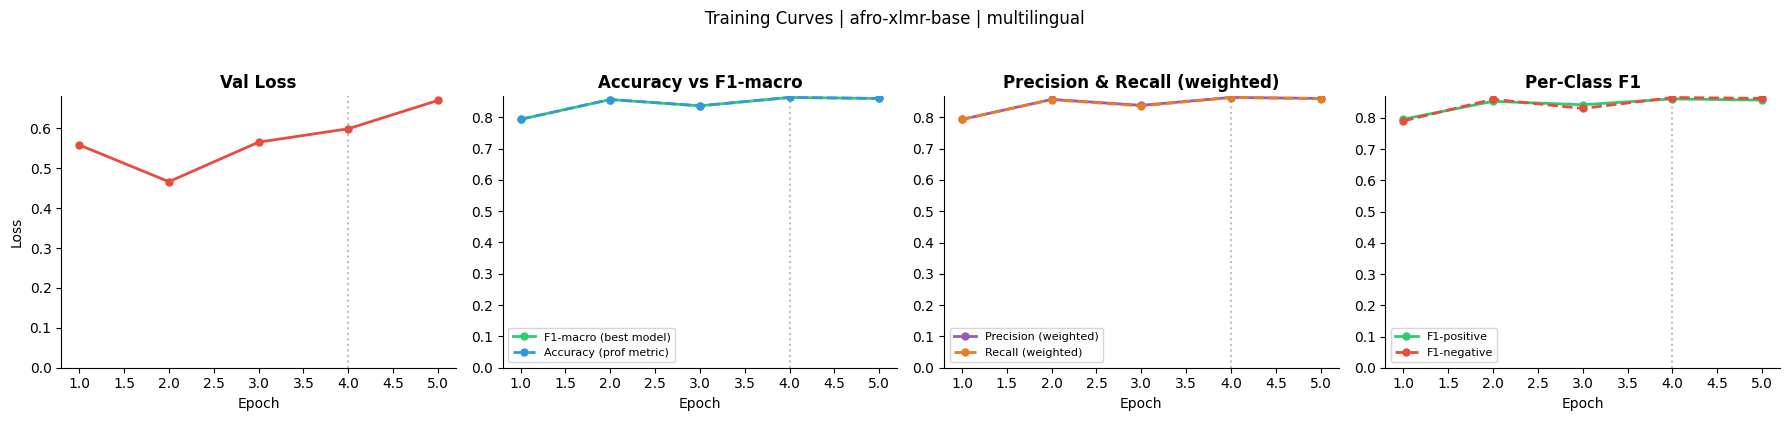

Saved to Drive: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/training_curves.png
Best epoch (F1-macro): 4


In [ ]:
log_history = trainer.state.log_history
eval_logs   = [l for l in log_history if 'eval_f1_macro' in l]

if eval_logs:
    epochs   = [l['epoch']                    for l in eval_logs]
    v_loss   = [l['eval_loss']                for l in eval_logs]
    v_f1     = [l['eval_f1_macro']            for l in eval_logs]
    v_acc    = [l['eval_accuracy']            for l in eval_logs]
    v_prec   = [l['eval_precision_weighted']  for l in eval_logs]
    v_rec    = [l['eval_recall_weighted']     for l in eval_logs]
    v_fp     = [l['eval_f1_pos']              for l in eval_logs]
    v_fn     = [l['eval_f1_neg']              for l in eval_logs]
    best_ep  = epochs[v_f1.index(max(v_f1))]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    kw = dict(linewidth=2, marker='o', markersize=5)

    # Panel 1: Loss
    axes[0].plot(epochs, v_loss, color='#e74c3c', **kw)
    axes[0].set_title('Val Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

    # Panel 2: Accuracy vs F1-macro
    axes[1].plot(epochs, v_f1,  color='#2ecc71', label='F1-macro (best model)', **kw)
    axes[1].plot(epochs, v_acc, color='#3498db', linestyle='--', label='Accuracy (prof metric)', **kw)
    axes[1].set_title('Accuracy vs F1-macro', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8)

    # Panel 3: Precision & Recall
    axes[2].plot(epochs, v_prec, color='#9b59b6', label='Precision (weighted)', **kw)
    axes[2].plot(epochs, v_rec,  color='#e67e22', linestyle='--', label='Recall (weighted)', **kw)
    axes[2].set_title('Precision & Recall (weighted)', fontweight='bold')
    axes[2].set_xlabel('Epoch'); axes[2].legend(fontsize=8)

    # Panel 4: Per-class F1
    axes[3].plot(epochs, v_fp, color='#2ecc71', label='F1-positive', **kw)
    axes[3].plot(epochs, v_fn, color='#e74c3c', linestyle='--', label='F1-negative', **kw)
    axes[3].set_title('Per-Class F1', fontweight='bold')
    axes[3].set_xlabel('Epoch'); axes[3].legend(fontsize=8)

    for ax in axes:
        ax.axvline(best_ep, color='gray', linestyle=':', alpha=0.5)
        ax.spines[['top','right']].set_visible(False)
        ax.set_ylim(0, None)

    plt.suptitle(
        f'Training Curves | {MODEL_NAME.split("/")[-1]} | {TRAIN_MODE}',
        fontsize=12, y=1.04
    )
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, 'training_curves.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to Drive: {path}')
    print(f'Best epoch (F1-macro): {best_ep:.0f}')
else:
    print('No eval logs found — training may not have run yet.')

## 11. Load Best Model & Evaluate Per Language
Loads the best model directly from Drive.

In [ ]:
# Load from Drive - whether trained or resuming
print(f'Loading best model from Drive: {MODEL_DIR}')
eval_model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
eval_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
eval_model.to(DEVICE)
eval_model.eval()

eval_args = TrainingArguments(
    output_dir             = CKPT_DIR,
    per_device_eval_batch_size = BATCH_SIZE * 2,
    fp16                   = (DEVICE == 'cuda'),
    report_to              = 'none',
    dataloader_num_workers = 0,
)
evaluator = Trainer(model=eval_model, args=eval_args, compute_metrics=compute_metrics)

results = {}
for lang in LANGUAGES:
    out    = evaluator.predict(test_ds[lang])
    y_pred = np.argmax(out.predictions, axis=-1)
    y_true = np.array([test_ds[lang][i]['labels'].item() for i in range(len(test_ds[lang]))])
    results[lang] = {
        'name'     : LANG_META[lang]['name'],
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision_weighted' : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted'    : recall_score(y_true, y_pred,    average='weighted', zero_division=0),
        'f1_macro' : f1_score(y_true, y_pred, average='macro'),
        'f1_pos'   : f1_score(y_true, y_pred, pos_label=LABEL2ID['positive'], average='binary'),
        'f1_neg'   : f1_score(y_true, y_pred, pos_label=LABEL2ID['negative'], average='binary'),
        'y_true': y_true, 'y_pred': y_pred,
    }
    print(f'\n━━━ {LANG_META[lang]["name"]} ({lang.upper()}) ━━━')
    print(classification_report(y_true, y_pred, labels=[0,1], target_names=LABELS, digits=4))

# Summary table
HDR = f'{"Language":12} {"Accuracy":>10} {"Precision":>11} {"Recall":>9} {"F1-macro":>10} {"F1-pos":>8} {"F1-neg":>8}'
print('\n' + '='*72)
print(HDR)
print('-'*72)
for lang, r in results.items():
    print(
        f"{r['name']:12} {r['accuracy']:>10.4f} "
        f"{r['precision_weighted']:>11.4f} {r['recall_weighted']:>9.4f} "
        f"{r['f1_macro']:>10.4f} {r['f1_pos']:>8.4f} {r['f1_neg']:>8.4f}"
    )

print()


Loading best model from Drive: /content/drive/MyDrive/Colab Notebooks/NollySenti/best_model



━━━ English (EN) ━━━
              precision    recall  f1-score   support

    positive     0.9373    0.9560    0.9465       250
    negative     0.9551    0.9360    0.9455       250

    accuracy                         0.9460       500
   macro avg     0.9462    0.9460    0.9460       500
weighted avg     0.9462    0.9460    0.9460       500




━━━ Yoruba (YO) ━━━
              precision    recall  f1-score   support

    positive     0.8188    0.9040    0.8593       250
    negative     0.8929    0.8000    0.8439       250

    accuracy                         0.8520       500
   macro avg     0.8558    0.8520    0.8516       500
weighted avg     0.8558    0.8520    0.8516       500




━━━ Hausa (HA) ━━━
              precision    recall  f1-score   support

    positive     0.8587    0.9240    0.8902       250
    negative     0.9177    0.8480    0.8815       250

    accuracy                         0.8860       500
   macro avg     0.8882    0.8860    0.8858       500
weighted avg     0.8882    0.8860    0.8858       500


Language       Accuracy   Precision    Recall   F1-macro   F1-pos   F1-neg
------------------------------------------------------------------------
English          0.9460      0.9462    0.9460     0.9460   0.9465   0.9455
Yoruba           0.8520      0.8558    0.8520     0.8516   0.8593   0.8439
Hausa            0.8860      0.8882    0.8860     0.8858   0.8902   0.8815



## 12. Confusion Matrices & Performance Charts

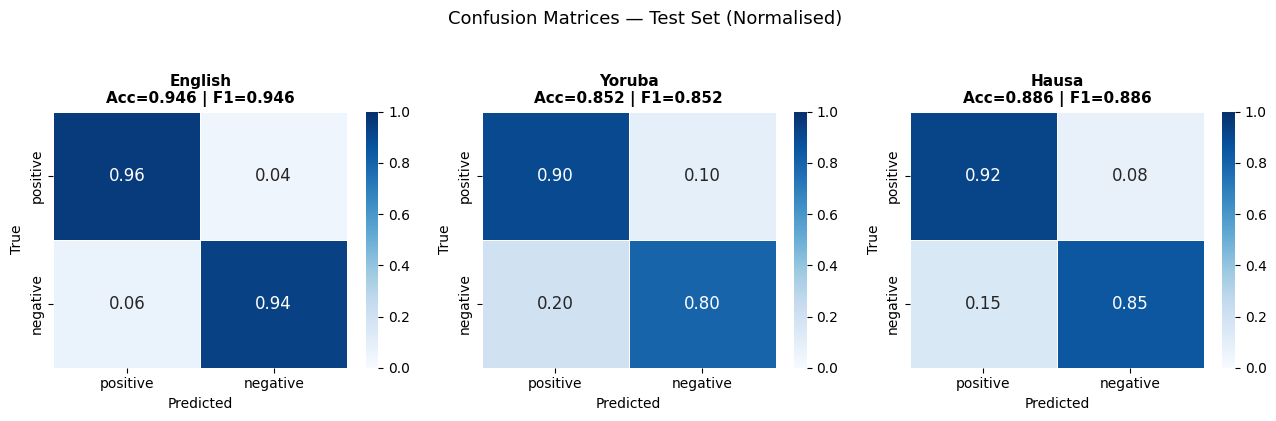

Saved: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, lang in zip(axes, LANGUAGES):
    r  = results[lang]
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    cn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cn, annot=True, fmt='.2f', ax=ax,
                xticklabels=LABELS, yticklabels=LABELS,
                cmap='Blues', linewidths=0.5, vmin=0, vmax=1, annot_kws={'size':12})
    ax.set_title(f"{r['name']}\nAcc={r['accuracy']:.3f} | F1={r['f1_macro']:.3f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — Test Set (Normalised)', fontsize=13, y=1.04)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'confusion_matrices.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

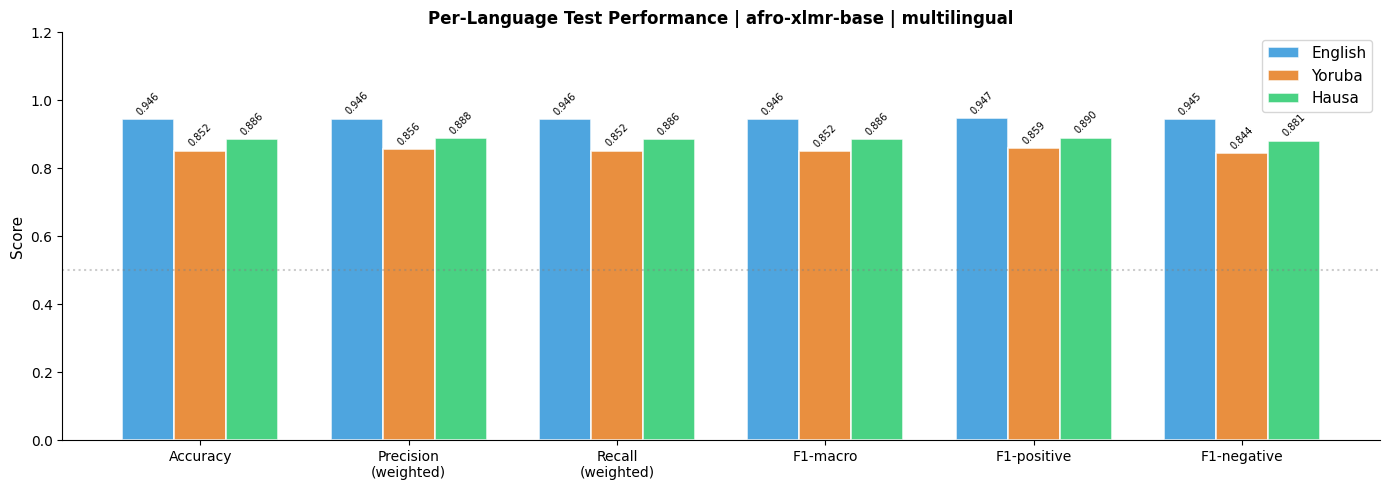

Saved: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/performance_chart.png


In [ ]:
metrics_list  = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_macro', 'f1_pos', 'f1_neg']
metric_labels = ['Accuracy', 'Precision\n(weighted)', 'Recall\n(weighted)', 'F1-macro', 'F1-positive', 'F1-negative']
x      = np.arange(len(metric_labels))
w      = 0.25
colors = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(14, 5))
for i_lang, lang in enumerate(LANGUAGES):
    r    = results[lang]
    vals = [r[m] for m in metrics_list]
    bars = ax.bar(x + i_lang*w, vals, w, label=r['name'],
                  color=colors[i_lang], alpha=0.87, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + w)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(
    f'Per-Language Test Performance | {MODEL_NAME.split("/")[-1]} | {TRAIN_MODE}',
    fontweight='bold', fontsize=12
)
ax.legend(fontsize=11)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.4)


ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'performance_chart.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')


## 13. Error Analysis

In [ ]:
# Load raw data or resume
if 'raw_data' not in dir():
    raw_data = {lang: load_dataset('Davlan/nollysenti', lang) for lang in LANGUAGES}

N = 5
for lang in LANGUAGES:
    r        = results[lang]
    col      = LANG_META[lang]['col']
    test_df  = raw_data[lang]['test'].to_pandas().reset_index(drop=True)
    err_mask = r['y_pred'] != r['y_true']
    n_err    = err_mask.sum()
    print(f'\n━━━ {LANG_META[lang]["name"]} — {n_err}/{len(r["y_true"])} errors ({100*n_err/len(r["y_true"]):.1f}%) ━━━')
    for idx in np.where(err_mask)[0][:N]:
        print(f'  True:{ID2LABEL[r["y_true"][idx]]:9} Pred:{ID2LABEL[r["y_pred"][idx]]:9} '
              f'{test_df.iloc[idx][col][:90]}...')


━━━ English — 27/500 errors (5.4%) ━━━
  True:positive  Pred:negative  Nollywoody producing fantastic works, which seemed to be just another sugar water romance ...
  True:positive  Pred:negative  Those negative reviews for this movie are a joke. People need to leave their personal feel...
  True:positive  Pred:negative  OK but WAY TOO LONG...
  True:positive  Pred:negative  Simply relating the narrative of Andrew Dosunmu’s seductive immigrant drama Mother of Geor...
  True:positive  Pred:negative  WARNING YOU HAVE GOT TO WATCH THE END OF THE CREDITS THROUGHOUT THIS MOVIE AS SOMETHING HA...

━━━ Yoruba — 74/500 errors (14.8%) ━━━
  True:positive  Pred:negative  Ó ní àwọn iṣẹ́ ìṣe ìṣèré nípasẹ̀ kemistri gíga láàrin àwọn òṣèré....
  True:positive  Pred:negative  Àwàdà àti ìgbádún....
  True:positive  Pred:negative  Eré náà kò pé ṣùgbọn ìyàlẹ̣́nu ni ó jẹ̣́...
  True:positive  Pred:negative  FÍÌMÙ ŃLÁ: Ó dára jùlọ ní ọdún 2020 yìí.. .  . .  Àwọn ipa tí àwọn òṣere...


## 14. Zero-Shot Cross-Lingual Baseline
Train on English only - evaluate on Yoruba & Hausa.

In [ ]:
zs_exists = os.path.exists(os.path.join(ZS_DIR, 'config.json'))

if not zs_exists:
    print('Training English-only zero-shot model...')
    en_train = load_and_tokenize(os.path.join(DATA_DIR,'en'), 'train', tokenizer, MODEL_TYPE)
    en_val   = load_and_tokenize(os.path.join(DATA_DIR,'en'), 'dev',   tokenizer, MODEL_TYPE)

    zs_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID,
        ignore_mismatched_sizes=True)

    zs_args = TrainingArguments(
        output_dir=f'{CKPT_DIR}_zs', num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE, per_device_eval_batch_size=BATCH_SIZE*2,
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO, max_grad_norm=MAX_GRAD_NORM,
        evaluation_strategy='epoch', save_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='f1_macro',
        fp16=(DEVICE=='cuda'), seed=SEED, report_to='none',
        save_total_limit=1, logging_steps=999999, dataloader_num_workers=0,
    )
    zs_trainer = Trainer(
        model=zs_model, args=zs_args, train_dataset=en_train, eval_dataset=en_val,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    zs_trainer.train()
    zs_trainer.save_model(ZS_DIR); tokenizer.save_pretrained(ZS_DIR)
    print(f'Zero-shot model saved to Drive: {ZS_DIR}')
    zs_evaluator = zs_trainer
else:
    print(f'Loading zero-shot model from Drive: {ZS_DIR}')
    zs_m = AutoModelForSequenceClassification.from_pretrained(ZS_DIR)
    zs_evaluator = Trainer(model=zs_m, args=eval_args, compute_metrics=compute_metrics)

print('\nZero-shot (EN-only) vs Multilingual:')
print(f'{"Language":12} {"EN-only F1":>12} {"Multi F1":>10} {"Δ":>8}')
print('-'*46)
for lang in LANGUAGES:
    out    = zs_evaluator.predict(test_ds[lang])
    yp_zs  = np.argmax(out.predictions, axis=-1)
    yt     = results[lang]['y_true']
    f1_zs  = f1_score(yt, yp_zs, average='macro')
    f1_mul = results[lang]['f1_macro']
    delta  = f1_mul - f1_zs
    sign   = '+' if delta >= 0 else ''
    print(f"{LANG_META[lang]['name']:12} {f1_zs:>12.4f} {f1_mul:>10.4f} {sign}{delta:>7.4f}")
print('\n+Δ = multilingual training helped')

Training English-only zero-shot model...
  Tokenising 1302 instances (train)...
  [ex 0] label=positive→0 | text=A steamy soap opera unfolding against the backdrop...
  [ex 1] label=positive→0 | text=An enormous amount of work and scrutiny went into ...
  Skipped 2 unknown-label instances
  Cached to Drive: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/en/cache_train_afro-xlmr-base_128.pkl
  Tokenising 100 instances (dev)...
  [ex 0] label=positive→0 | text=AMAZING!. . . . Stella acting, stella production, ...
  [ex 1] label=positive→0 | text=It is globally minded filmmaking that is also comf...
  Cached to Drive: /content/drive/MyDrive/Colab Notebooks/NollySenti/data/en/cache_dev_afro-xlmr-base_128.pkl


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at Davlan/afro-xlmr-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Macro,F1 Pos,F1 Neg
1,No log,0.349342,0.890000,0.897797,0.890000,0.889458,0.881720,0.897196
2,No log,0.337264,0.910000,0.910164,0.910000,0.909991,0.909091,0.910891
3,No log,0.433912,0.900000,0.900641,0.900000,0.899960,0.897959,0.901961
4,No log,0.559095,0.890000,0.890156,0.890000,0.889989,0.888889,0.891089


Zero-shot model saved to Drive: /content/drive/MyDrive/Colab Notebooks/NollySenti/zeroshot_model

Zero-shot (EN-only) vs Multilingual:
Language       EN-only F1   Multi F1        Δ
----------------------------------------------


English            0.9280     0.9460 + 0.0180


Yoruba             0.7720     0.8516 + 0.0796


Hausa              0.8680     0.8858 + 0.0178

+Δ = multilingual training helped


## 15. Save All Results to Drive

In [ ]:
import json as _json

# Per-language results files
for lang in LANGUAGES:
    r = results[lang]
    res_path = os.path.join(OUTPUT_DIR, f'results_{lang}.txt')
    with open(res_path, 'w') as f:
        f.write(f'loss             = N/A (test set)\n')
        f.write(f'accuracy         = {r["accuracy"]:.5f}\n')
        f.write(f'precision        = {r["precision_weighted"]:.5f}\n')
        f.write(f'recall           = {r["recall_weighted"]:.5f}\n')
        f.write(f'f1_macro         = {r["f1_macro"]:.5f}\n')
        f.write(f'f1_positive      = {r["f1_pos"]:.5f}\n')
        f.write(f'f1_negative      = {r["f1_neg"]:.5f}\n')
    print(f'Saved: {res_path}')

    # Prediction file
    col  = LANG_META[lang]['col']
    tdf  = raw_data[lang]['test'].to_pandas().reset_index(drop=True)
    pred_path = os.path.join(OUTPUT_DIR, f'predictions_{lang}.txt')
    with open(pred_path, 'w', encoding='utf-8') as f:
        for idx, pred_id in enumerate(r['y_pred']):
            text = tdf.iloc[idx][col].replace('\t', ' ').replace('\n', ' ')
            f.write(f'{text}\t{ID2LABEL[pred_id]}\n')
    print(f'Saved: {pred_path}')

# Summary CSV
rows = []
for lang, r in results.items():
    rows.append({
        'language'           : r['name'],
        'lang_code'          : lang,
        'model'              : MODEL_NAME,
        'train_mode'         : TRAIN_MODE,
        'accuracy'           : round(r['accuracy'],            4),
        'precision_weighted' : round(r['precision_weighted'],  4),
        'recall_weighted'    : round(r['recall_weighted'],     4),
        'f1_macro'           : round(r['f1_macro'],            4),
        'f1_positive'        : round(r['f1_pos'],              4),
        'f1_negative'        : round(r['f1_neg'],              4),
    })
results_df = pd.DataFrame(rows)
csv_path   = os.path.join(OUTPUT_DIR, 'summary_results.csv')
results_df.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')

# Experiment log JSON
log = {
    'date'        : pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'),
    'dataset'     : 'Davlan/nollysenti',
    'languages'   : LANGUAGES,
    'model'       : MODEL_NAME,
    'train_mode'  : TRAIN_MODE,
    'max_len'     : MAX_LEN,
    'batch_size'  : BATCH_SIZE,
    'lr'          : LEARNING_RATE,
    'epochs'      : NUM_EPOCHS,
    'seed'        : SEED,
    'label_order' : LABEL2ID,
    'test_results': {
        lang: {
            'accuracy'           : round(r['accuracy'],           4),
            'precision_weighted' : round(r['precision_weighted'], 4),
            'recall_weighted'    : round(r['recall_weighted'],    4),
            'f1_macro'           : round(r['f1_macro'],           4),
        }
        for lang, r in results.items()
    }
}
try:
    log['best_f1_val'] = round(trainer.state.best_metric, 4)
except:
    pass

log_path = os.path.join(OUTPUT_DIR, 'experiment_log.json')
with open(log_path, 'w') as f:
    _json.dump(log, f, indent=2)
print(f'Saved: {log_path}')

print('\n✅ All results saved to Drive')
print()
print(results_df.to_string(index=False))


Saved: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/results_en.txt
Saved: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/predictions_en.txt
Saved: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/results_yo.txt
Saved: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/predictions_yo.txt
Saved: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/results_ha.txt
Saved: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/predictions_ha.txt

Saved: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/summary_results.csv
Saved: /content/drive/MyDrive/Colab Notebooks/NollySenti/outputs/experiment_log.json

✅ All results saved to Drive

language lang_code                 model   train_mode  accuracy  precision_weighted  recall_weighted  f1_macro  f1_positive  f1_negative
 English        en Davlan/afro-xlmr-base multilingual     0.946              0.9462            0.946    0.9460       0.9465       0.9455
  Yoruba        yo Davlan/afro-x

## 16. Custom Inference
Loads model from Drive

In [ ]:
from transformers import pipeline as hf_pipeline

clf = hf_pipeline('text-classification', model=MODEL_DIR, tokenizer=MODEL_DIR,
                  device=0 if DEVICE=='cuda' else -1)

demos = [
    ('en','positive', 'This Nollywood film is absolutely brilliant! World-class storytelling.'),
    ('en','negative', 'Terrible movie. Wasted two hours. The acting was painful to watch.'),
    ('yo','positive', 'Fiimu yi dara pupo! Mo nifẹ rẹ gaan.'),
    ('yo','negative', 'Fiimu yi buru pupọ. Akoko mi ti jẹ.'),
    ('ha','positive', 'Wannan fim yana da kyau sosai! Na ji dadin sa.'),
    ('ha','negative', 'Fim din ya yi muni. Ban ji dadin sa ba.'),
]

print(f'{"Lang":8}{"True":12}{"Predicted":12}{"Conf":>8}  {"OK":>4}  Review')
print('─'*80)
correct = 0
for lang, true_lbl, text in demos:
    out     = clf(text, truncation=True, max_length=MAX_LEN)[0]
    pred    = out['label']
    conf    = out['score']
    ok      = '✅' if pred == true_lbl else '❌'
    correct += (pred == true_lbl)
    print(f"{LANG_META[lang]['name'][:3]:8}{true_lbl:12}{pred:12}{conf:>8.4f}  {ok}  {text[:48]}...")
print(f'\nDemo accuracy: {correct}/{len(demos)}')

Lang    True        Predicted       Conf    OK  Review
────────────────────────────────────────────────────────────────────────────────
Eng     positive    positive      0.9984  ✅  This Nollywood film is absolutely brilliant! Wor...
Eng     negative    negative      0.9961  ✅  Terrible movie. Wasted two hours. The acting was...
Yor     positive    positive      0.9980  ✅  Fiimu yi dara pupo! Mo nifẹ rẹ gaan....
Yor     negative    negative      0.9876  ✅  Fiimu yi buru pupọ. Akoko mi ti jẹ....
Hau     positive    positive      0.9981  ✅  Wannan fim yana da kyau sosai! Na ji dadin sa....
Hau     negative    negative      0.9925  ✅  Fim din ya yi muni. Ban ji dadin sa ba....

Demo accuracy: 6/6


##17. Push Fine-tuned model to Hugging Face Hub




In [ ]:
!pip install huggingface_hub --quiet

In [ ]:
from google.colab import userdata
import os

# Read from Colab secrets and set as environment variable
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")


In [ ]:
from huggingface_hub import HfApi, login
from google.colab import userdata
import os

# Log in to Hugging Face Hub using a stored token
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    login(token=HF_TOKEN)
    print("✅ Logged in to Hugging Face Hub.")
except Exception as e:
    print(f"❌ Failed to log in to Hugging Face Hub. Make sure you have a token named 'HF_TOKEN' in Colab secrets. Error: {e}")


# Define model name for the Hub
your_hf_repo_id = "emwania/nollysenti-afro-xlmr-base-en-yo-ha"


✅ Logged in to Hugging Face Hub.


In [ ]:
# Push `eval_model` and `eval_tokenizer`
if 'eval_model' in locals() and 'eval_tokenizer' in locals():
    print(f"\nPushing model '{your_hf_repo_id}' to Hugging Face Hub...")
    eval_model.push_to_hub(your_hf_repo_id)
    eval_tokenizer.push_to_hub(your_hf_repo_id)
    print(f"✅ Model and tokenizer pushed to Hugging Face Hub: https://huggingface.co/{your_hf_repo_id}")
else:
    print("❌ 'eval_model' or 'eval_tokenizer' not found. Please ensure the evaluation section (Part 11) has been run.")


Pushing model 'emwania/nollysenti-afro-xlmr-base-en-yo-ha' to Hugging Face Hub...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...042wk0t/model.safetensors:   0%|          |  556kB / 1.11GB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...7/sentencepiece.bpe.model: 100%|##########| 5.07MB / 5.07MB            

  ...mpvbrj6mk7/tokenizer.json:   1%|1         |  249kB / 17.1MB            

✅ Model and tokenizer pushed to Hugging Face Hub: https://huggingface.co/emwania/nollysenti-afro-xlmr-base-en-yo-ha


## 18. Test Pushed Model from Hugging Face Hub

Verify that the model is on the Hugging Face Hub and it can be loaded and used like any other pre-trained model.

In [ ]:
from transformers import pipeline as hf_pipeline

if 'your_hf_repo_id' not in locals():
    print("❌ 'your_hf_repo_id' is not defined. Please create it.")
else:
    print(f"\nLoading model '{your_hf_repo_id}' from Hugging Face Hub for testing...")
    try:
        # Load the model directly from the Hub
        test_clf = hf_pipeline('text-classification', model=your_hf_repo_id, tokenizer=your_hf_repo_id,
                               device=0 if DEVICE=='cuda' else -1)
        print("✅ Model loaded successfully from Hugging Face Hub!")

        # Use the same demo examples as before
        demos = [
            ('en','positive', 'This Nollywood film is absolutely brilliant! World-class storytelling.'),
            ('en','negative', 'Terrible movie. Wasted two hours. The acting was painful to watch.'),
            ('yo','positive', 'Fiimu yi dara pupo! Mo nifẹ rẹ gaan.'),
            ('yo','negative', 'Fiimu yi buru pupọ. Akoko mi ti jẹ.'),
            ('ha','positive', 'Wannan fim yana da kyau sosai! Na ji dadin sa.'),
            ('ha','negative', 'Fim din ya yi muni. Ban ji dadin sa ba.'),
        ]

        print(f'{"Lang":8}{"True":12}{"Predicted":12}{"Conf":>8}  {"OK":>4}  Review')
        print('─'*80)
        correct = 0
        for lang, true_lbl, text in demos:
            out     = test_clf(text, truncation=True, max_length=MAX_LEN)[0]
            pred    = out['label']
            conf    = out['score']
            ok      = '✅' if pred == true_lbl else '❌'
            correct += (pred == true_lbl)
            print(f"{LANG_META[lang]['name'][:3]:8}{true_lbl:12}{pred:12}{conf:>8.4f}  {ok}  {text[:48]}...")
        print(f'\nDemo accuracy: {correct}/{len(demos)}')

    except Exception as e:
        print(f"❌ Failed to load or use the model from Hugging Face Hub. Error: {e}")


Loading model 'emwania/nollysenti-afro-xlmr-base-en-yo-ha' from Hugging Face Hub for testing...


config.json:   0%|          | 0.00/934 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

✅ Model loaded successfully from Hugging Face Hub!
Lang    True        Predicted       Conf    OK  Review
────────────────────────────────────────────────────────────────────────────────
Eng     positive    positive      0.9984  ✅  This Nollywood film is absolutely brilliant! Wor...
Eng     negative    negative      0.9961  ✅  Terrible movie. Wasted two hours. The acting was...
Yor     positive    positive      0.9980  ✅  Fiimu yi dara pupo! Mo nifẹ rẹ gaan....
Yor     negative    negative      0.9876  ✅  Fiimu yi buru pupọ. Akoko mi ti jẹ....
Hau     positive    positive      0.9981  ✅  Wannan fim yana da kyau sosai! Na ji dadin sa....
Hau     negative    negative      0.9925  ✅  Fim din ya yi muni. Ban ji dadin sa ba....

Demo accuracy: 6/6


## 17. What's Saved on Drive

In [ ]:
print(f'📂 {DRIVE_ROOT}')
for root, dirs, files in os.walk(DRIVE_ROOT):
    dirs.sort()
    level = root.replace(DRIVE_ROOT,'').count(os.sep)
    indent = '  ' * level
    folder = os.path.basename(root)
    if level > 0: print(f'{indent}📁 {folder}/')
    subind = '  ' * (level + 1)
    for fname in sorted(files):
        fpath = os.path.join(root, fname)
        size  = os.path.getsize(fpath)
        unit  = 'MB' if size > 1e6 else 'KB'
        sval  = size/1e6 if size > 1e6 else size/1e3
        print(f'{subind}📄 {fname} ({sval:.1f} {unit})')

📂 /content/drive/MyDrive/Colab Notebooks/NollySenti
  📁 best_model/
    📄 config.json (0.9 KB)
    📄 model.safetensors (1112.2 MB)
    📄 sentencepiece.bpe.model (5.1 MB)
    📄 special_tokens_map.json (1.0 KB)
    📄 tokenizer.json (17.1 MB)
    📄 tokenizer_config.json (1.1 KB)
    📄 training_args.bin (5.6 KB)
  📁 checkpoints/
    📁 checkpoint-656/
      📄 config.json (0.9 KB)
      📄 model.safetensors (1112.2 MB)
      📄 optimizer.pt (2224.5 MB)
      📄 rng_state.pth (14.6 KB)
      📄 scheduler.pt (1.5 KB)
      📄 trainer_state.json (5.0 KB)
      📄 training_args.bin (5.6 KB)
    📁 checkpoint-820/
      📄 config.json (0.9 KB)
      📄 model.safetensors (1112.2 MB)
      📄 optimizer.pt (2224.5 MB)
      📄 rng_state.pth (14.6 KB)
      📄 scheduler.pt (1.5 KB)
      📄 trainer_state.json (6.0 KB)
      📄 training_args.bin (5.6 KB)
  📁 checkpoints_zs/
    📁 checkpoint-164/
      📄 config.json (0.9 KB)
      📄 model.safetensors (1112.2 MB)
      📄 optimizer.pt (2224.5 MB)
      📄 rng_state.pth

## 19. Building a Multilingual Voice AI with LiveKit

This section will focus on setting up LiveKit for real-time voice applications and integrating multilingual speech capabilities.

In [ ]:
# Install LiveKit Python SDK
!pip install livekit-api livekit --quiet

print('✅ LiveKit libraries installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 9.1 MB/s eta 0:00:00
✅ LiveKit libraries installed.


To truly build a voice AI with LiveKit, you would typically run a LiveKit server and connect a client application (e.g., a web or mobile app) that captures and sends audio. Within Colab, we can set up the Python server-side components and conceptually demonstrate interactions.

First, let's look at setting up a basic LiveKit Room connection.

In [ ]:
from livekit.api import AccessToken
from livekit.api.grants import VideoGrant
import os

# You would typically get these from your LiveKit server configuration
# For demonstration, we'll use placeholders. Replace with actual keys if you set up a server.
LIVEKIT_API_KEY = os.getenv("LIVEKIT_API_KEY", "YOUR_LIVEKIT_API_KEY")
LIVEKIT_API_SECRET = os.getenv("LIVEKIT_API_SECRET", "YOUR_LIVEKIT_API_SECRET")
LIVEKIT_URL = os.getenv("LIVEKIT_URL", "ws://localhost:7880") # Default local URL

if LIVEKIT_API_KEY == "YOUR_LIVEKIT_API_KEY":
    print("⚠️  Please set your LiveKit API Key and Secret as environment variables or replace placeholders.")
    print("You can also use Colab secrets for LIVEKIT_API_KEY and LIVEKIT_API_SECRET.")

# Create a token for joining a room
def create_livekit_token(room_name: str, participant_identity: str, participant_name: str) -> str:
    grant = VideoGrant(room_join=True, room=room_name)
    token = AccessToken(LIVEKIT_API_KEY, LIVEKIT_API_SECRET).with_grants(grant)
    token.identity = participant_identity
    token.name = participant_name
    return token.to_jwt()

# Example usage (this will only generate a token, not connect to a server without a running LiveKit instance)
room = "my-multilingual-room"
identity = "colab-ai-agent"
name = "Colab AI"

auth_token = create_livekit_token(room, identity, name)

print(f"Generated LiveKit access token for room '{room}' and participant '{name}'.")
print("Next steps would involve running a LiveKit server and connecting clients using this token.")
print("We then need to integrate multilingual Speech-to-Text and Text-to-Speech models.")

ModuleNotFoundError: No module named 'livekit.api.grants'